In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
test_df = pd.read_csv('data/test.csv')
train_df = pd.read_csv('data/train.csv')
submission_test_df = pd.read_csv('data/sample_submission.csv')


In [3]:
train_df.head()
train_df.shape

(7613, 5)

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        3263 non-null   int64 
 1   keyword   3237 non-null   object
 2   location  2158 non-null   object
 3   text      3263 non-null   object
dtypes: int64(1), object(3)
memory usage: 102.1+ KB


### With just Text and target

In [6]:
# Drop last 3 Columns

train_df.drop(columns = ['keyword','location'], inplace = True)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      7613 non-null   int64 
 1   text    7613 non-null   object
 2   target  7613 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 178.6+ KB


In [7]:
test_df.drop(columns = ['keyword','location'], inplace = True)
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      3263 non-null   int64 
 1   text    3263 non-null   object
dtypes: int64(1), object(1)
memory usage: 51.1+ KB


In [8]:
# check for null values

train_df.isnull().sum()

id        0
text      0
target    0
dtype: int64

In [9]:
# check for duplicate values
train_df.duplicated().sum()

#remove Duplicate values
train_df = train_df.drop_duplicates(keep='first')

### EDA

In [10]:
train_df['target'].value_counts()

target
0    4342
1    3271
Name: count, dtype: int64

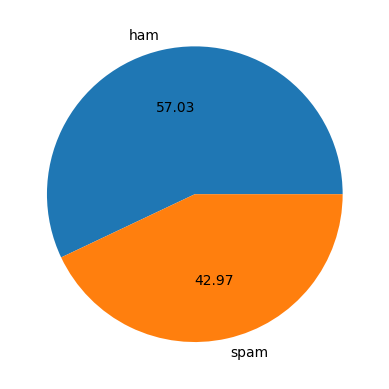

In [11]:
import matplotlib.pyplot as plt
plt.pie(train_df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [12]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\91939\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\91939\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\91939\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [13]:
import spacy

# Load the English model
nlp = spacy.load("en_core_web_sm")

train_df['num_characters'] = train_df['text'].apply(len)
train_df['num_words'] = train_df['text'].apply(lambda x: len([token.text for token in nlp(x) if not token.is_punct]))
train_df['num_sentences'] = train_df['text'].apply(lambda x: len(list(nlp(x).sents)))

train_df.head()


,id,text,target,num_characters,num_words,num_sentences
0,1,Our Deeds are the Reason of this #earthquake M...,1,69,13,1
1,4,Forest fire near La Ronge Sask. Canada,1,38,7,2
2,5,All residents asked to 'shelter in place' are ...,1,133,22,2
3,6,"13,000 people receive #wildfires evacuation or...",1,65,8,1
4,7,Just got sent this photo from Ruby #Alaska as ...,1,88,16,1


### Data Preprocessing
```python
Lower case
Tokenization
Removing special char
removing stop words and puncutuation
stemming
```


In [14]:
from nltk.corpus import stopwords
from string import punctuation
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

ps = PorterStemmer()
wnl = WordNetLemmatizer()

In [15]:
import spacy
from string import punctuation

nlp = spacy.load("en_core_web_sm")

def transform_text(text):
    text = text.lower()
    doc = nlp(text)
    
    cleaned_tokens = []
    for token in doc:
        if token.is_alpha and not token.is_stop and token.text not in punctuation:
            cleaned_tokens.append(token.lemma_)
    
    return " ".join(cleaned_tokens)


In [16]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'go to home soon want talk stuff anymore tonight k cry today'

In [17]:
train_df['transformed_text'] = train_df['text'].apply(transform_text)

In [18]:
test_df['transform_text'] = test_df['text'].apply(transform_text)

In [19]:
spam_corpus = []
for msg in train_df[train_df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [20]:
print(len(spam_corpus))

27972


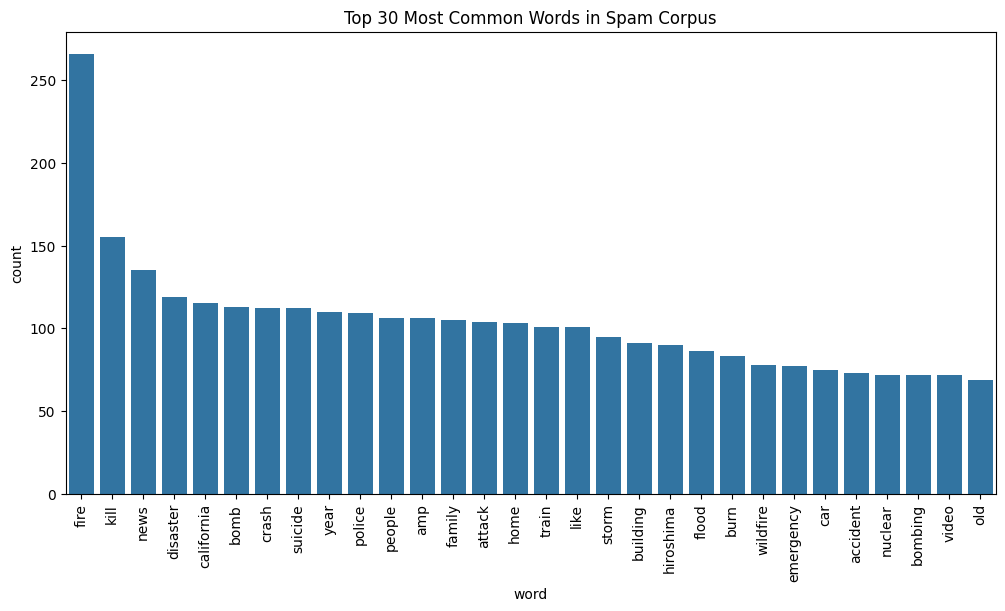

In [21]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Get the 30 most common tokens
common_tokens = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

# Plot using seaborn
plt.figure(figsize=(12,6))
sns.barplot(x='word', y='count', data=common_tokens)
plt.xticks(rotation='vertical')
plt.title("Top 30 Most Common Words in Spam Corpus")
plt.show()


In [22]:
ham_corpus = []
for msg in train_df[train_df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

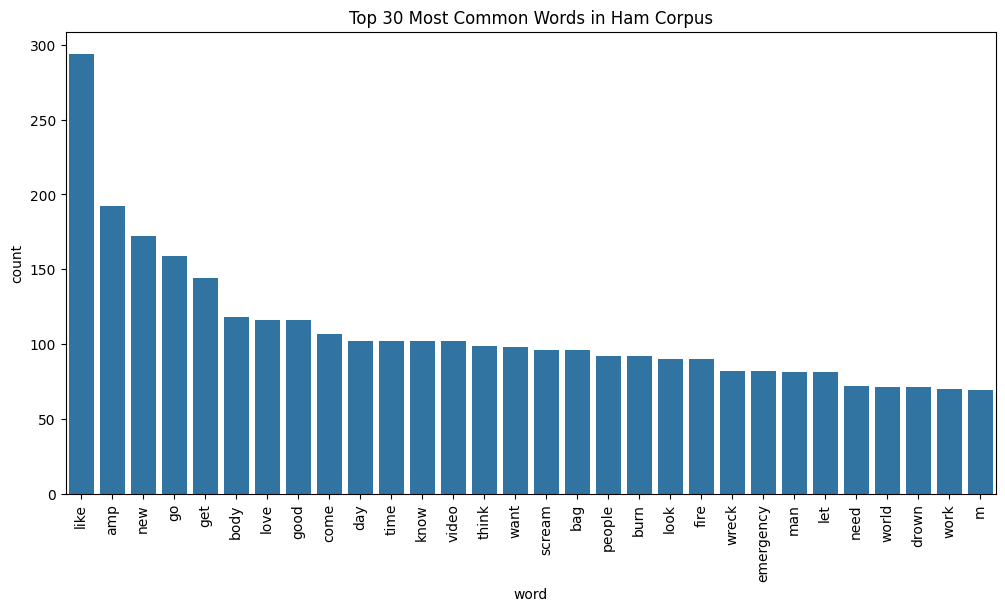

In [23]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the 30 most common words in ham corpus
ham_common = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x='word', y='count', data=ham_common)
plt.xticks(rotation='vertical')
plt.title("Top 30 Most Common Words in Ham Corpus")
plt.show()


### 4. Model Building

In [24]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [25]:
X = cv.fit_transform(train_df['transformed_text']).toarray()
X = tfidf.fit_transform(train_df['transformed_text']).toarray()

In [26]:
Y = cv.fit_transform(test_df['transform_text']).toarray()
Y = tfidf.fit_transform(test_df['transform_text']).toarray()

In [27]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(7613, 11349))

In [28]:
y = train_df['target'].values

In [29]:
y

array([1, 1, 1, ..., 1, 1, 1], shape=(7613,))

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state=2)

In [32]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,f1_score

In [33]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [34]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.5856861457649376
[[395 475]
 [156 497]]
0.5113168724279835


In [35]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.8030203545633617
[[775  95]
 [205 448]]
0.8250460405156538


In [36]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.8115561391989494
[[782  88]
 [199 454]]
0.8376383763837638


# running all the models 

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [38]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [39]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    # 'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [40]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    f1score = f1_score(y_test,y_pred)
    
    return accuracy,precision,f1score

In [ ]:
accuracy_scores = []
precision_scores = []
f1_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision,f1score = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    print("F1 Score - ",f1score)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    f1_scores.append(f1score)

For  SVC
Accuracy -  0.7918581746552856
Precision -  0.8
F1 Score -  0.7386644682605111
For  KN
Accuracy -  0.6769533814839134
Precision -  0.8744186046511628
F1 Score -  0.43317972350230416
For  NB
Accuracy -  0.8095863427445831
Precision -  0.8246869409660107
F1 Score -  0.7607260726072608
For  DT
Accuracy -  0.6250820748522653
Precision -  0.8796296296296297
F1 Score -  0.24967148488830487
For  LR
Accuracy -  0.7787261982928431
Precision -  0.7981132075471699
F1 Score -  0.7151310228233305
For  RF
Accuracy -  0.7734734077478661
Precision -  0.7636986301369864
F1 Score -  0.7210994341147938
For  AdaBoost
Accuracy -  0.6165462902166776
Precision -  0.8876404494382022
F1 Score -  0.21293800539083557
For  ETC
Accuracy -  0.778069599474721
Precision -  0.7528089887640449
F1 Score -  0.7351097178683386
For  GBDT
Accuracy -  0.7202889034799738
Precision -  0.8673139158576052
F1 Score -  0.5571725571725572
For  xgb
Accuracy -  0.7537754432042022
Precision -  0.792016806722689
F1 Score -  0.

In [42]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'f1_score':f1_scores,'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Accuracy',ascending=False)

NameError: name 'f1_scores' is not defined

In [ ]:
performance_df 

,Algorithm,f1_score,Accuracy,Precision
2,NB,0.760726,0.809586,0.824687
0,SVC,0.738664,0.791858,0.800000
4,LR,0.715131,0.778726,0.798113
7,ETC,0.735110,0.778070,0.752809
5,RF,0.721099,0.773473,0.763699
9,xgb,0.667848,0.753775,0.792017
8,GBDT,0.557173,0.720289,0.867314
1,KN,0.433180,0.676953,0.874419
3,DT,0.249671,0.625082,0.879630
6,AdaBoost,0.212938,0.616546,0.887640


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      3263 non-null   int64 
 1   text    3263 non-null   object
dtypes: int64(1), object(1)
memory usage: 51.1+ KB


In [ ]:
sample = pd.read_csv('data/sample_submission.csv')

In [ ]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3263 entries, 0 to 3262
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      3263 non-null   int64
 1   target  3263 non-null   int64
dtypes: int64(2)
memory usage: 51.1 KB


In [ ]:
def sample_file_creator(name,y_pred):
    pred=pd.DataFrame(y_pred)
    datasets=pd.concat([sample['id'],pred],axis=1)
    datasets.columns=['Id','target']
    datasets.to_csv('outputs/'+ name+'_sample_submission_1.csv',index=False)

In [ ]:
for name,clf in clfs.items():

    y_pred= clf.predict(tfidf.transform(test_df['text']).toarray())
    sample_file_creator(name,y_pred)
    
    print("For ",name)

For  SVC
For  KN
For  NB
For  DT
For  LR
For  RF
For  AdaBoost
For  ETC
For  GBDT
For  xgb


In [ ]:
for name,clf in clfs.items():
    op_df = pd.read_csv('outputs/'+name+'_sample_submission.csv')
    diff = op_df['SalePrice'].compare(y_test)
    new_col=(diff['self']-diff['other'])
    print(name, new_col.mean())